# Aplicación común de cartera y escenarios de estrés

Este notebook aplica **exactamente el mismo motor** a cuatro fuentes de escenarios:

1. distribución histórica del bloque de test;
2. peores drawdowns históricos reservados;
3. shocks prefijados y transparentes;
4. block bootstrap incondicional, block bootstrap condicionado y artefactos generativos disponibles (CVAE, flow y GAN).

La cartera parte de 100.000 USD, con 60 % BTC y 40 % ETH, sin rebalanceo, apalancamiento ni costes. Todos los escenarios producen valor cada seis horas, pérdida final, pérdida máxima, máximo drawdown, VaR y Expected Shortfall.

> **Alcance de esta ejecución:** se conserva el bootstrap incondicional de 12 pasos y 5.000 escenarios como control. El baseline principal es el bootstrap condicionado de 12 pasos y 128 vecinos, con 20 escenarios por cada una de las 1.826 condiciones de test. CVAE, flow y GAN usan el mismo presupuesto condicionado de 36.520 trayectorias.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from crypto_generative.data import ProjectScenarioLoader
from crypto_generative.data.artifacts import write_csv_atomic, write_json_atomic
from crypto_generative.models import (
    BlockBootstrapConfig,
    ConditionalMultivariateBlockBootstrap,
    MultivariateBlockBootstrap,
    frozen_conditional_bootstrap_config,
)
from crypto_generative.portfolio import (
    BuyAndHoldPortfolio,
    PortfolioConfig,
    PortfolioStressApplication,
    ScenarioCategory,
    StressScenarioSet,
    default_prefixed_scenarios,
)

SEED = 42
N_BOOTSTRAP = 5_000
SCENARIOS_PER_CONDITION = 20
OUTPUT_DIR = ROOT / 'outputs/portfolio_stress_notebook'
pd.set_option('display.max_columns', 100)
print('Raíz:', ROOT.name)

Raíz: Taller_Generativos


## 1. Datos congelados y cartera

El cargador invierte la normalización con los parámetros de train y conserva las fechas del split. Para el control incondicional reconstruye 8.300 retornos temporales únicos distribuidos en diez segmentos contiguos. Para el baseline condicionado carga 4.710 trayectorias de train y sus 4.710 vectores normalizados de condición, alineando cada bloque candidato con el estado de mercado inmediatamente anterior.

In [2]:
loader = ProjectScenarioLoader(
    ROOT / 'data/normalized/binance/btc_eth_6h_c240_t120_train_normalized.npz',
    ROOT / 'data/splits/binance/btc_eth_6h_c240_t120_purged_split.npz',
    ROOT / 'data/splits/binance/btc_eth_6h_c240_t120_purged_split_index.csv',
    ROOT / 'data/processed/binance/btc_eth_6h_panel.csv',
)
test = loader.load_split('test')
train = loader.load_split('train')
train_conditions = loader.load_normalized_conditions(train.sample_ids)
test_conditions = loader.load_normalized_conditions(test.sample_ids)
bootstrap_train = loader.load_bootstrap_training_series()
portfolio = BuyAndHoldPortfolio(PortfolioConfig())

pd.DataFrame({
    'elemento': [
        'test histórico', 'trayectorias train', 'condiciones train',
        'retornos únicos de train', 'segmentos train', 'valor inicial',
    ],
    'valor': [
        len(test.log_returns), len(train.log_returns), len(train_conditions),
        len(bootstrap_train.log_returns),
        len(np.unique(bootstrap_train.segment_ids)),
        portfolio.config.initial_value,
    ],
})

,elemento,valor
0,test histórico,1826.0
1,trayectorias train,4710.0
2,condiciones train,4710.0
3,retornos únicos de train,8300.0
4,segmentos train,10.0
5,valor inicial,100000.0


## 2. Escenarios históricos, prefijados y baseline

La distribución histórica completa sirve para describir el riesgo observado fuera de muestra. El subconjunto de peores drawdowns es deliberadamente una selección de cola: sirve para inspeccionar crisis, pero su VaR/ES **no** debe interpretarse como cobertura. Los shocks prefijados aplican BTC −30 % y ETH −40 % de forma rápida, gradual y con recuperación parcial.

Incluimos dos baselines con bloques conjuntos de 12 velas de seis horas: el control incondicional genera 5.000 trayectorias desde la serie histórica única; el condicionado selecciona uniformemente entre los 128 estados de train más próximos a cada condición de test y genera 36.520 trayectorias. Bajo el nombre estable `block_bootstrap` se guarda el modelo condicionado, para que los artefactos posteriores utilicen la comparación justa.

In [3]:
scenario_sets = [
    StressScenarioSet(
        name='historical_test_distribution',
        category=ScenarioCategory.HISTORICAL,
        log_returns=test.log_returns,
        labels=test.labels,
        metadata={'split': 'test', 'overlapping_windows': True},
    )
]
worst_ids = portfolio.select_stress_paths(test.log_returns, 10, criterion='maximum_drawdown')
scenario_sets.append(StressScenarioSet(
    name='historical_worst_drawdowns',
    category=ScenarioCategory.HISTORICAL,
    log_returns=test.log_returns[worst_ids],
    labels=tuple(test.labels[index] for index in worst_ids),
    metadata={'selection': 'largest_portfolio_maximum_drawdown', 'tail_selected': True},
))
scenario_sets.extend(default_prefixed_scenarios())

unconditional_bootstrap = MultivariateBlockBootstrap(BlockBootstrapConfig(
    block_length=12, horizon_steps=120, random_state=SEED + 5_000
)).fit(bootstrap_train.log_returns, bootstrap_train.segment_ids)
scenario_sets.append(StressScenarioSet(
    name='block_bootstrap_unconditional',
    category=ScenarioCategory.BASELINE,
    log_returns=unconditional_bootstrap.sample(N_BOOTSTRAP),
    metadata={
        'conditioned': False,
        'block_length_steps': 12,
        'seed': SEED + 5_000,
    },
))

conditional_config = frozen_conditional_bootstrap_config(
    random_state=SEED + 6_000,
    horizon_steps=test.log_returns.shape[1],
)
conditional_bootstrap = ConditionalMultivariateBlockBootstrap(
    conditional_config
).fit(train.log_returns, train_conditions)
repeated_test_conditions = np.repeat(
    test_conditions, SCENARIOS_PER_CONDITION, axis=0
)
scenario_sets.append(StressScenarioSet(
    name='block_bootstrap',
    category=ScenarioCategory.BASELINE,
    log_returns=conditional_bootstrap.sample(
        len(repeated_test_conditions),
        cond=repeated_test_conditions,
    ),
    metadata={
        'conditioned': True,
        'block_length_steps': conditional_config.block_length,
        'n_neighbors': conditional_config.n_neighbors,
        'scenarios_per_condition': SCENARIOS_PER_CONDITION,
        'test_conditions': len(test_conditions),
        'seed': conditional_config.random_state,
    },
))
print('Conjuntos base:', [scenario.name for scenario in scenario_sets])

Conjuntos base: ['historical_test_distribution', 'historical_worst_drawdowns', 'prefixed_fast_crash', 'prefixed_gradual_selloff', 'prefixed_crash_half_recovery', 'block_bootstrap_unconditional', 'block_bootstrap']


## 3. Incorporación automática de modelos generativos

CVAE, flow y GAN guardan el mismo NPZ. En esta ejecución se han incorporado los tres artefactos, cada uno con 36.520 trayectorias —20 por cada una de las 1.826 condiciones de test—, sin cambiar ninguna fórmula de cartera. Ese presupuesto coincide exactamente con el bootstrap condicionado. Si algún artefacto no está presente, el notebook sigue siendo ejecutable con histórico, shocks y los dos baselines, y muestra cuál falta.

In [4]:
generative_artifacts = {
    'cvae': ROOT / 'outputs/cvae_best/test_scenarios.npz',
    'normalizing_flow': ROOT / 'outputs/normalizing_flow_best/test_scenarios.npz',
    'conditional_gan': ROOT / 'outputs/conditional_gan_best/test_scenarios.npz',
}
loaded, missing = [], []
for name, path in generative_artifacts.items():
    if path.exists():
        scenario_sets.append(loader.load_generated_scenarios(name, path, expected_reference=test))
        loaded.append(name)
    else:
        missing.append(name)
print('Generadores incorporados:', loaded or 'ninguno')
print('Artefactos pendientes de regenerar:', missing or 'ninguno')

Generadores incorporados: ['cvae', 'normalizing_flow', 'conditional_gan']
Artefactos pendientes de regenerar: ninguno


## 4. Informe común

Cada fila usa la misma cartera y las mismas definiciones. `maximum_loss` mide la peor pérdida respecto a los 100.000 USD iniciales; `maximum_drawdown` mide la caída desde el máximo previo alcanzado dentro de la trayectoria.

In [5]:
report = PortfolioStressApplication(portfolio).run(scenario_sets)
summary_table = pd.DataFrame(report.summary_records())
summary_table[[
    'scenario_set', 'category', 'scenario_count', 'mean_final_loss_fraction',
    'q95_final_loss_fraction', 'q95_maximum_loss_fraction',
    'q95_maximum_drawdown', 'worst_final_loss_fraction',
]]

,scenario_set,category,scenario_count,mean_final_loss_fraction,q95_final_loss_fraction,q95_maximum_loss_fraction,q95_maximum_drawdown,worst_final_loss_fraction
0,historical_test_distribution,historical,1826,-0.005216,0.271125,0.316798,0.320503,0.375722
1,historical_worst_drawdowns,historical,10,0.290019,0.328211,0.361422,0.393368,0.338776
2,prefixed_fast_crash,prefixed,1,0.340000,0.340000,0.340000,0.340000,0.340000
3,prefixed_gradual_selloff,prefixed,1,0.340000,0.340000,0.340000,0.340000,0.340000
4,prefixed_crash_half_recovery,prefixed,1,0.188165,0.188165,0.340000,0.340000,0.188165
5,block_bootstrap_unconditional,baseline,5000,-0.055722,0.287596,0.353495,0.386908,0.629292
6,block_bootstrap,baseline,36520,-0.047387,0.318915,0.353878,0.381155,0.683983
7,cvae,generative,36520,-0.049943,0.179308,0.217428,0.253295,0.525219
8,normalizing_flow,generative,36520,-0.041861,0.203413,0.242326,0.271247,0.579882
9,conditional_gan,generative,36520,-0.141231,0.180211,0.214370,0.287379,0.653499


In [6]:
risk_table = pd.DataFrame(report.risk_records())
risk_table[[
    'scenario_set', 'category', 'scenario_count', 'confidence_level',
    'value_at_risk_fraction', 'expected_shortfall_fraction',
    'value_at_risk_amount', 'expected_shortfall_amount',
]]

,scenario_set,category,scenario_count,confidence_level,value_at_risk_fraction,expected_shortfall_fraction,value_at_risk_amount,expected_shortfall_amount
0,historical_test_distribution,historical,1826,0.95,0.271125,0.302357,27112.483946,30235.745843
1,historical_test_distribution,historical,1826,0.99,0.324836,0.335168,32483.568689,33516.794197
2,historical_worst_drawdowns,historical,10,0.95,0.328211,0.338776,32821.120468,33877.646930
3,historical_worst_drawdowns,historical,10,0.99,0.336663,0.338776,33666.341637,33877.646930
4,prefixed_fast_crash,prefixed,1,0.95,0.340000,0.340000,34000.000000,34000.000000
5,prefixed_fast_crash,prefixed,1,0.99,0.340000,0.340000,34000.000000,34000.000000
6,prefixed_gradual_selloff,prefixed,1,0.95,0.340000,0.340000,34000.000000,34000.000000
7,prefixed_gradual_selloff,prefixed,1,0.99,0.340000,0.340000,34000.000000,34000.000000
8,prefixed_crash_half_recovery,prefixed,1,0.95,0.188165,0.188165,18816.531638,18816.531638
9,prefixed_crash_half_recovery,prefixed,1,0.99,0.188165,0.188165,18816.531638,18816.531638


## 5. Trayectorias severas comparables

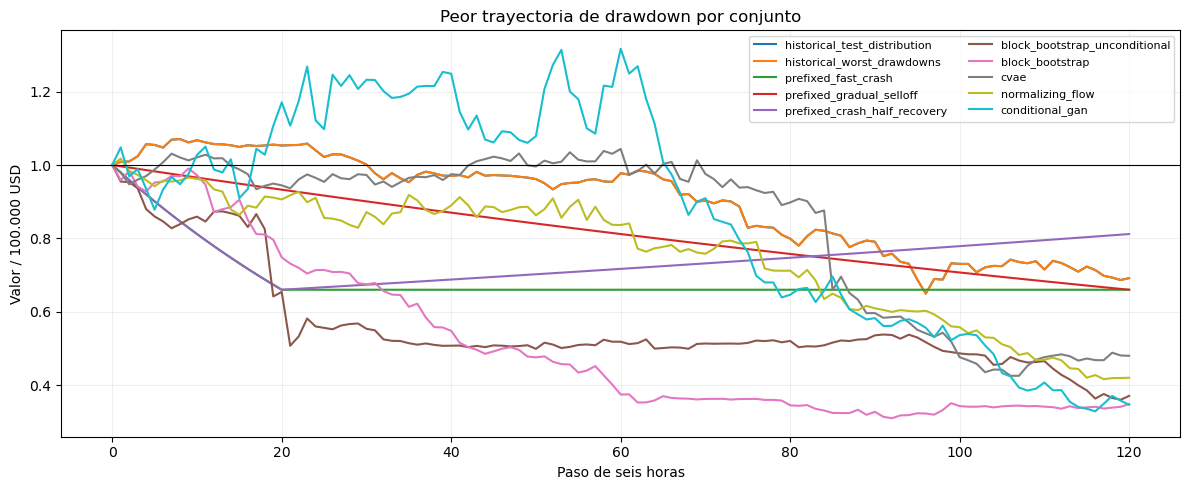

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, summary in report.scenarios.items():
    ax.plot(np.asarray(summary.worst_drawdown_value_path) / portfolio.config.initial_value, label=name)
ax.axhline(1.0, color='black', linewidth=0.8)
ax.set(title='Peor trayectoria de drawdown por conjunto', xlabel='Paso de seis horas', ylabel='Valor / 100.000 USD')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

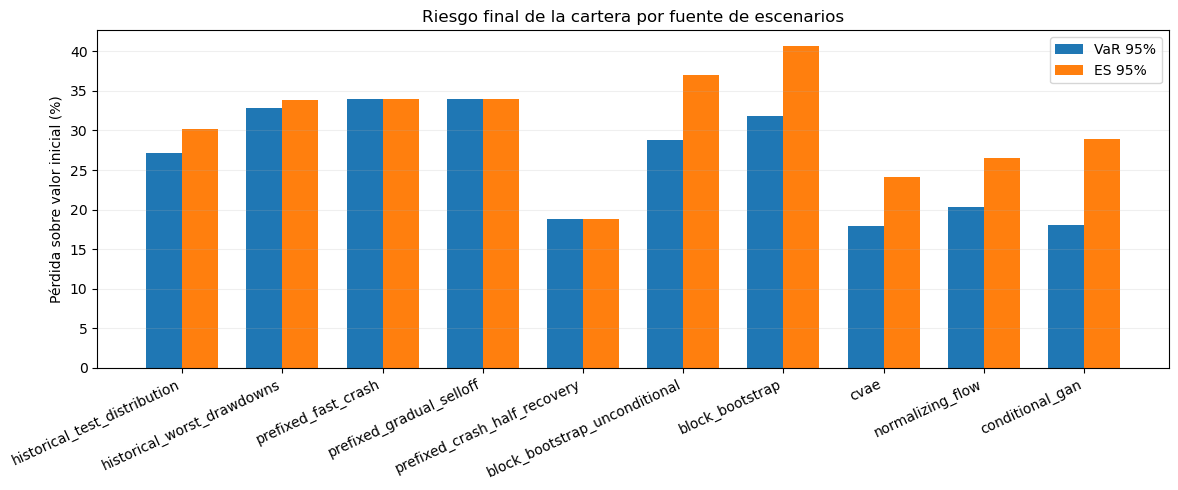

In [8]:
plot_risk = risk_table.loc[risk_table['confidence_level'].eq(0.95)].copy()
x = np.arange(len(plot_risk))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.18, 100 * plot_risk['value_at_risk_fraction'], 0.36, label='VaR 95%')
ax.bar(x + 0.18, 100 * plot_risk['expected_shortfall_fraction'], 0.36, label='ES 95%')
ax.set_xticks(x, plot_risk['scenario_set'], rotation=25, ha='right')
ax.set(title='Riesgo final de la cartera por fuente de escenarios', ylabel='Pérdida sobre valor inicial (%)')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Guardado reproducible

El JSON conserva configuración, métricas, metadatos y las peores trayectorias. Los dos CSV separan resumen de escenarios y comparación VaR/ES.

In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
write_json_atomic(report.to_dict(), OUTPUT_DIR / 'stress_report.json')
write_csv_atomic(report.summary_records(), tuple(report.summary_records()[0]), OUTPUT_DIR / 'scenario_summary.csv')
write_csv_atomic(report.risk_records(), tuple(report.risk_records()[0]), OUTPUT_DIR / 'risk_comparison.csv')
print('Resultados guardados en:', OUTPUT_DIR.relative_to(ROOT))

Resultados guardados en: outputs/portfolio_stress_notebook


## Conclusión

La aplicación desacopla la valoración de cartera del generador: histórico, shocks, bootstrap y modelos neuronales consumen retornos logarítmicos con el mismo orden `[BTC, ETH]` y producen métricas comparables. El escenario prefijado BTC −30 % / ETH −40 % implica una pérdida terminal del 34 % para la cartera 60/40; la versión con recuperación parcial conserva el mismo drawdown máximo, pero reduce la pérdida final.

El bloque histórico completo sirve como referencia descriptiva fuera de muestra, pero sus ventanas se solapan y no constituyen episodios independientes ni un backtest formal de cobertura. Los peores episodios históricos y los shocks prefijados son ejercicios de severidad, no muestras aleatorias: sus percentiles describen esos conjuntos y no probabilidades verdaderas de mercado.

El control incondicional ya era más conservador que el test histórico: estima VaR/ES del **28,76 %/37,00 %** al 95 % y del **42,17 %/48,44 %** al 99 %, frente a **27,11 %/30,24 %** y **32,48 %/33,52 %** en el histórico.

El condicionamiento acentúa esa cola. El bootstrap condicionado alcanza VaR/ES del **31,89 %/40,63 %** al 95 % y del **46,42 %/52,42 %** al 99 %. Frente al control, aumenta el VaR en 3,13 y 4,25 puntos porcentuales y el ES en 3,64 y 3,97 puntos. Su pérdida final del percentil 95 es 31,89 %, su drawdown máximo del percentil 95 es 38,12 % y la peor pérdida terminal observada llega al 68,40 %. Esta última cifra debe leerse con cautela porque el condicionado contiene muchas más simulaciones que el control.

Al 95 %, CVAE (**17,93 %/24,16 %**), flow (**20,34 %/26,54 %**) y GAN (**18,02 %/28,96 %**) quedan por debajo del VaR/ES histórico y de ambos bootstraps. Al 99 % la ordenación cambia: CVAE alcanza **28,32 %/33,69 %**, flow **30,14 %/35,37 %** y GAN **35,89 %/42,79 %**, todavía por debajo del bootstrap condicionado. La GAN supera al histórico en ambas medidas al 99 %, mientras CVAE y flow mantienen menor VaR pero un ES ligeramente superior.

El resultado defendible es que, bajo las condiciones observadas en test, el bootstrap condicionado genera la distribución agregada más severa entre los métodos probabilísticos comparados. Esto no demuestra mejor calibración: esta aplicación resume riesgo agregado. La cobertura condición por condición debe evaluarse con el `TrajectoryEvaluator` y sus tasas de excepción.

También aparece una señal que conviene vigilar: la GAN estima una pérdida terminal media de −14,1 % —es decir, una ganancia media— frente a −0,5 % en el test histórico. Ese sesgo central optimista convive con una cola extrema severa; los resultados son útiles como escenarios de estrés, pero no bastan por sí solos para afirmar que el modelo esté calibrado.